# Model Comparison: GRU-GCN v1 vs v2
## Traffic Flow Prediction — I-95 / I-66, Northern Virginia

### What changed in v2?
| Feature | v1 | v2 |
|---|---|---|
| Graph adjacency | Fixed (from road network, row-normalised) | **Learnable** — strength of each road connection is optimised end-to-end |
| Graph depth | 1 GCN layer (direct neighbours only) | **2 GCN layers** (reaches 2-hop neighbours) |
| Residual connection | None | **Skip connection** from pre-graph representation |

The core motivation is the SADL paper finding: knowing *which* sensors are connected (topology)
is easy, but the *strength* of correlation between them is not uniform and varies with context.
v2 lets the model learn these strengths from data.

**Outputs**
- Comparison metrics table (RMSE, MAE, MAPE, R²) on the held-out test set
- `animation_v1_monday.html` — animated Monday predictions from v1
- `animation_v2_monday.html` — animated Monday predictions from v2


## 1  Setup & data loading

In [1]:
import os, sys, warnings, subprocess
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
warnings.filterwarnings('ignore')

DATA_PATH   = "dataset.npz"
MODEL_V1    = "model.pth"
MODEL_V2    = "model_v2.pth"
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run train_traffic.py or train_traffic_v2.py once first.")

data     = np.load(DATA_PATH)
X_train  = data["X_train"]   # [1261, 36, 48]
Y_train  = data["Y_train"]   # [1261, 36]
X_test   = data["X_test"]    # [840,  36, 48]
Y_test   = data["Y_test"]    # [840,  36]
adj_mat  = data["adj_mat"]   # [36,   36]

n_sensors = adj_mat.shape[0]
print(f"Train {X_train.shape}  Test {X_test.shape}  Adj {adj_mat.shape}")


Device: cpu
Train (1261, 36, 48)  Test (840, 36, 48)  Adj (36, 36)


## 2  Model definitions

In [2]:
# ── V1: original GRU-GCN (fixed adjacency) ───────────────────────────────────
class GRU_GCN_v1(nn.Module):
    def __init__(self, hidden_size=64, static_size=38, dropout=0.1):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_size,
                          num_layers=1, batch_first=True)
        self.static_MLP = nn.Sequential(
            nn.Linear(static_size, 32), nn.ReLU(), nn.Dropout(dropout))
        self.combine = nn.Sequential(
            nn.Linear(hidden_size + 32, hidden_size), nn.ReLU())
        self.graph_layer = nn.Sequential(
            nn.Linear(hidden_size, hidden_size), nn.ReLU(), nn.LayerNorm(hidden_size))
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x, adj):
        seq, static = x[:, :, :10], x[:, :, 10:]
        B, N, T = seq.shape
        _, h = self.gru(seq.reshape(B * N, T, 1))
        h = h[-1].reshape(B, N, -1)
        s = self.static_MLP(static)
        z = self.combine(torch.cat([h, s], dim=-1))
        z = torch.einsum("ij,bjf->bif", adj, z)
        z = self.graph_layer(z)
        return self.head(z).squeeze(-1)


# ── V2: learnable adjacency + 2-layer GCN + residual ─────────────────────────
class AdaptiveGraphConv(nn.Module):
    def __init__(self, in_size, out_size, n_sensors, adj_mask):
        super().__init__()
        self.register_buffer("adj_mask", adj_mask.float())
        self.edge_logits = nn.Parameter(torch.zeros(n_sensors, n_sensors))
        self.linear = nn.Linear(in_size, out_size)
        self.norm   = nn.LayerNorm(out_size)

    def get_adj(self):
        w   = torch.sigmoid(self.edge_logits) * self.adj_mask
        w   = w + torch.eye(w.shape[0], device=w.device)
        deg = w.sum(dim=1, keepdim=True).clamp(min=1e-6)
        return w / deg

    def forward(self, z):
        z_agg = torch.einsum("ij,bjf->bif", self.get_adj(), z)
        return self.norm(torch.relu(self.linear(z_agg)))


class GRU_GCN_v2(nn.Module):
    def __init__(self, hidden_size=64, static_size=38, dropout=0.1,
                 n_sensors=36, adj_mask=None):
        super().__init__()
        self.gru = nn.GRU(input_size=1, hidden_size=hidden_size,
                          num_layers=1, batch_first=True)
        self.static_mlp = nn.Sequential(
            nn.Linear(static_size, 32), nn.ReLU(), nn.Dropout(dropout))
        self.combine = nn.Sequential(
            nn.Linear(hidden_size + 32, hidden_size), nn.ReLU())
        if adj_mask is None:
            adj_mask = torch.ones(n_sensors, n_sensors)
        self.gcn1 = AdaptiveGraphConv(hidden_size, hidden_size, n_sensors, adj_mask)
        self.gcn2 = AdaptiveGraphConv(hidden_size, hidden_size, n_sensors, adj_mask)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x, adj=None):
        seq, static = x[:, :, :10], x[:, :, 10:]
        B, N, T = seq.shape
        _, h = self.gru(seq.reshape(B * N, T, 1))
        h = h[-1].reshape(B, N, -1)
        s = self.static_mlp(static)
        z = self.combine(torch.cat([h, s], dim=-1))
        z_out = self.gcn2(self.gcn1(z)) + z    # residual
        return self.head(z_out).squeeze(-1)

    def get_learned_adj(self):
        return self.gcn1.get_adj().detach().cpu().numpy()


## 3  Train / load both models

In [3]:
EPOCHS     = 60    # change to 100 for full training
HIDDEN     = 32
BATCH      = 32
LR         = 1e-3
DROPOUT    = 0.1
SEED       = 523
VAL_FRAC   = 0.2

def set_seed(seed):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)


def normalize_adj(adj):
    adj = adj.astype(np.float32)
    adj = adj + np.eye(adj.shape[0], dtype=np.float32)
    deg = adj.sum(axis=1, keepdims=True)
    return adj / np.maximum(deg, 1e-6)


class TrafficDataset(Dataset):
    def __init__(self, X, Y, cont_idx, x_mean, x_std, y_mean, y_std):
        self.X = X.astype(np.float32); self.Y = Y.astype(np.float32)
        self.cont_idx = cont_idx
        self.x_mean = x_mean; self.x_std = x_std
        self.y_mean = y_mean; self.y_std = y_std
    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        x = self.X[i].copy(); y = self.Y[i].copy()
        x[:, self.cont_idx] = (x[:, self.cont_idx] - self.x_mean) / self.x_std
        y = (y - self.y_mean) / self.y_std
        return torch.tensor(x, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)


def build_loaders(X_tr, Y_tr, cont_idx, x_mean, x_std, y_mean, y_std, batch):
    ds = TrafficDataset(X_tr, Y_tr, cont_idx, x_mean, x_std, y_mean, y_std)
    return DataLoader(ds, batch_size=batch, shuffle=True)


def run_training(model, adj_t, loaders, epochs, lr=1e-3, weight_decay=1e-3,
                 patience=15, min_delta=1e-4, y_mean=0, y_std=1):
    loss_fn   = nn.HuberLoss(delta=1.0)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    y_mean_t  = torch.tensor(y_mean, dtype=torch.float32, device=DEVICE)
    y_std_t   = torch.tensor(y_std,  dtype=torch.float32, device=DEVICE)
    train_loader, val_loader = loaders
    best_rmse, best_state, no_imp = float("inf"), None, 0
    history = []

    for epoch in range(epochs):
        model.train()
        tl = 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(x, adj_t), y)
            loss.backward(); optimizer.step()
            tl += loss.item() * len(y)
        tl /= len(train_loader.dataset)

        model.eval()
        sq = ab = n = 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                p = model(x, adj_t)
                pr = p * y_std_t + y_mean_t
                yr = y * y_std_t + y_mean_t
                sq += float(torch.sum((pr - yr)**2)); ab += float(torch.sum(torch.abs(pr - yr)))
                n  += yr.numel()
        vrmse = np.sqrt(sq / max(n, 1)); vmae = ab / max(n, 1)

        history.append({"epoch": epoch+1, "train_loss": tl, "val_rmse": vrmse, "val_mae": vmae})
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"  epoch {epoch+1:3d}  train={tl:.4f}  val_rmse={vrmse:.4f}  val_mae={vmae:.4f}")

        if vrmse < best_rmse - min_delta:
            best_rmse = vrmse
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience:
            print(f"  Early stopping epoch {epoch+1} | best RMSE={best_rmse:.4f}")
            break

    model.load_state_dict(best_state)
    return model, pd.DataFrame(history), best_rmse


In [4]:
set_seed(SEED)

# ── Shared data prep ──────────────────────────────────────────────────────────
n = len(X_train)
idx = np.arange(n); np.random.shuffle(idx)
split = int((1 - VAL_FRAC) * n)
tr_idx, val_idx = idx[:split], idx[split:]

X_tr, Y_tr   = X_train[tr_idx], Y_train[tr_idx]
X_val, Y_val = X_train[val_idx], Y_train[val_idx]

cont_idx = list(range(10)) + [39]
x_mean = X_tr[:, :, cont_idx].mean(axis=(0, 1))
x_std  = X_tr[:, :, cont_idx].std(axis=(0, 1)) + 1e-6
y_mean = float(Y_tr.mean()); y_std = float(Y_tr.std()) + 1e-6

adj_norm = normalize_adj(adj_mat)
adj_t    = torch.tensor(adj_norm, dtype=torch.float32).to(DEVICE)
adj_mask = torch.tensor((adj_mat > 0.5).astype(np.float32))

static_size = X_train.shape[-1] - 10

def make_loaders():
    train_ds = TrafficDataset(X_tr,  Y_tr,  cont_idx, x_mean, x_std, y_mean, y_std)
    val_ds   = TrafficDataset(X_val, Y_val, cont_idx, x_mean, x_std, y_mean, y_std)
    return (DataLoader(train_ds, batch_size=BATCH, shuffle=True),
            DataLoader(val_ds,   batch_size=BATCH, shuffle=False))

# ── V1 ────────────────────────────────────────────────────────────────────────
if os.path.exists(MODEL_V1):
    print("Loading V1 from", MODEL_V1)
    ckpt1  = torch.load(MODEL_V1, map_location=DEVICE, weights_only=False)
    model1 = GRU_GCN_v1(hidden_size=int(ckpt1["hidden_size"]),
                         static_size=static_size,
                         dropout=float(ckpt1.get("dropout", 0.1))).to(DEVICE)
    model1.load_state_dict(ckpt1["model_state_dict"])
    history1 = None
    x_mean1 = ckpt1["x_mean"].numpy(); x_std1 = ckpt1["x_std"].numpy()
    y_mean1 = float(ckpt1["y_mean"]); y_std1  = float(ckpt1["y_std"])
    print("  V1 loaded OK")
else:
    print("Training V1 ...")
    model1   = GRU_GCN_v1(hidden_size=HIDDEN, static_size=static_size, dropout=DROPOUT).to(DEVICE)
    model1, history1, _ = run_training(model1, adj_t, make_loaders(), EPOCHS,
                                        y_mean=y_mean, y_std=y_std)
    x_mean1, x_std1, y_mean1, y_std1 = x_mean, x_std, y_mean, y_std

# ── V2 ────────────────────────────────────────────────────────────────────────
if os.path.exists(MODEL_V2):
    print("Loading V2 from", MODEL_V2)
    ckpt2  = torch.load(MODEL_V2, map_location=DEVICE, weights_only=False)
    mask   = ckpt2.get("adj_mask", adj_mask)
    model2 = GRU_GCN_v2(hidden_size=int(ckpt2["hidden_size"]),
                         static_size=static_size,
                         dropout=float(ckpt2.get("dropout", 0.1)),
                         n_sensors=n_sensors, adj_mask=mask).to(DEVICE)
    model2.load_state_dict(ckpt2["model_state_dict"])
    history2 = None
    x_mean2 = ckpt2["x_mean"].numpy(); x_std2 = ckpt2["x_std"].numpy()
    y_mean2 = float(ckpt2["y_mean"]); y_std2  = float(ckpt2["y_std"])
    print("  V2 loaded OK")
else:
    print("Training V2 ...")
    model2   = GRU_GCN_v2(hidden_size=HIDDEN, static_size=static_size, dropout=DROPOUT,
                           n_sensors=n_sensors, adj_mask=adj_mask).to(DEVICE)
    model2, history2, _ = run_training(model2, adj_t, make_loaders(), EPOCHS,
                                        y_mean=y_mean, y_std=y_std)
    x_mean2, x_std2, y_mean2, y_std2 = x_mean, x_std, y_mean, y_std

model1.eval(); model2.eval()
print("Both models ready.")


Loading V1 from model.pth
  V1 loaded OK
Loading V2 from model_v2.pth
  V2 loaded OK
Both models ready.


## 4  Test-set evaluation

In [5]:
def predict_all(model, X, adj, x_mean, x_std, y_mean, y_std, cont_idx, batch=64):
    ds     = TrafficDataset(X, np.zeros((len(X), n_sensors)),
                            cont_idx, x_mean, x_std, y_mean, y_std)
    loader = DataLoader(ds, batch_size=batch, shuffle=False)
    preds  = []
    with torch.no_grad():
        for xb, _ in loader:
            p = model(xb.to(DEVICE), adj)
            preds.append((p * y_std + y_mean).cpu().numpy())
    return np.concatenate(preds, axis=0)   # [N_test, 36]


pred1 = predict_all(model1, X_test, adj_t, x_mean1, x_std1, y_mean1, y_std1, cont_idx)
pred2 = predict_all(model2, X_test, adj_t, x_mean2, x_std2, y_mean2, y_std2, cont_idx)

# Y_test is already in original units (the dataset Y values are pre-normalised
# to [0,1] by the data provider; our model y_mean/y_std stats are of that [0,1]
# distribution, so denormalised predictions are back in [0,1] space too)
y_true = Y_test

def metrics(true, pred, name):
    err   = pred - true
    rmse  = float(np.sqrt(np.mean(err**2)))
    mae   = float(np.mean(np.abs(err)))
    # MAPE (avoid /0 by masking near-zero true values)
    mask  = true > 0.05
    mape  = float(np.mean(np.abs(err[mask] / true[mask])) * 100)
    ss_res = np.sum(err**2); ss_tot = np.sum((true - true.mean())**2)
    r2    = float(1 - ss_res / max(ss_tot, 1e-9))
    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE (%)": mape, "R²": r2}

rows = [metrics(y_true, pred1, "V1  GRU-GCN (fixed adj)"),
        metrics(y_true, pred2, "V2  GRU-GCN (learnable adj, 2-layer)")]
df_metrics = pd.DataFrame(rows).set_index("Model")
print(df_metrics.to_string())


                                          RMSE       MAE   MAPE (%)        R²
Model                                                                        
V1  GRU-GCN (fixed adj)               0.055267  0.038453  14.038864  0.926947
V2  GRU-GCN (learnable adj, 2-layer)  0.036367  0.024723   9.094002  0.968368


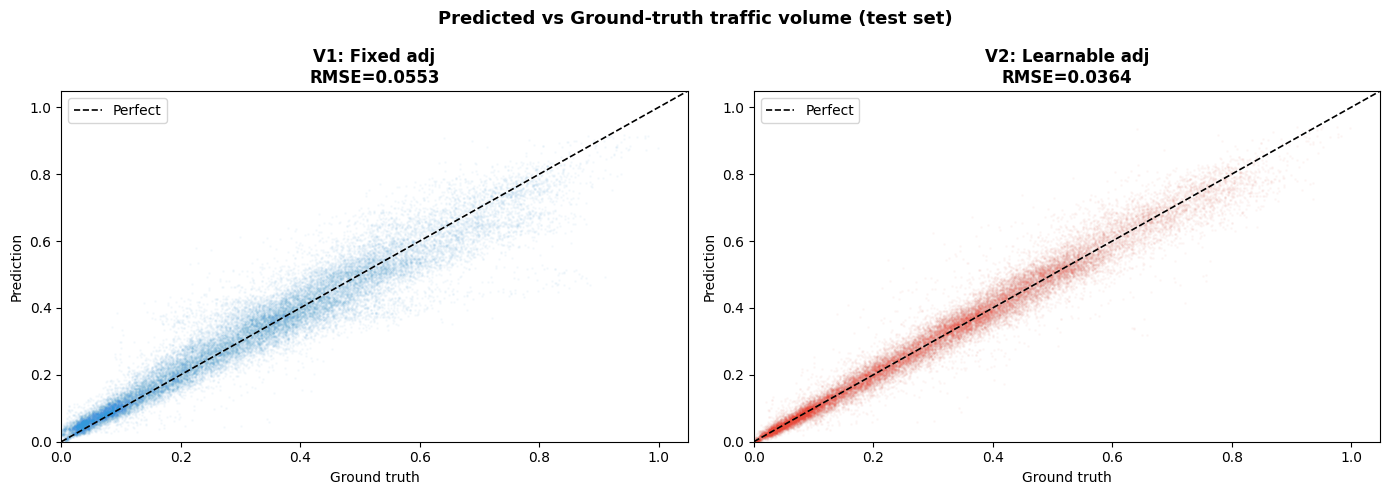

Saved comparison_scatter.png


In [6]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for col_idx, (ax, pred, name, col) in enumerate(zip(axes,
                                [pred1, pred2],
                                ["V1: Fixed adj", "V2: Learnable adj"],
                                ["#3498db", "#e74c3c"])):
    flat_t = y_true.ravel()
    flat_p = pred.ravel()
    lim    = max(flat_t.max(), flat_p.max()) * 1.05
    ax.scatter(flat_t, flat_p, alpha=0.03, s=1, color=col)
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1.2, label="Perfect")
    ax.set_xlabel("Ground truth"); ax.set_ylabel("Prediction")
    rmse_val = df_metrics["RMSE"].iloc[col_idx]
    ax.set_title(f"{name}\nRMSE={rmse_val:.4f}", fontweight='bold')
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.legend()

plt.suptitle("Predicted vs Ground-truth traffic volume (test set)", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("comparison_scatter.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved comparison_scatter.png")


## 5  Learned adjacency (V2 — what changed from the road network)

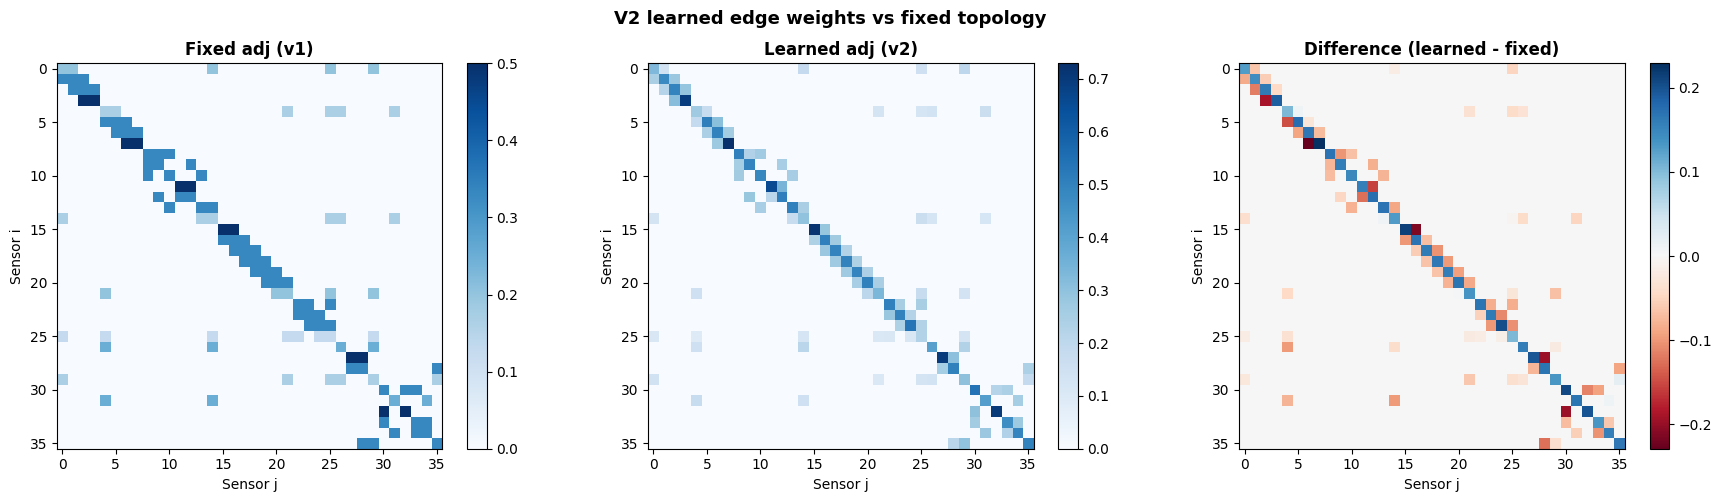

Saved learned_adj.png


In [7]:
learned_adj = model2.get_learned_adj()   # [36, 36]
fixed_adj   = normalize_adj(adj_mat)     # [36, 36]

diff = learned_adj - fixed_adj

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mat, title, cmap in zip(
        axes,
        [fixed_adj, learned_adj, diff],
        ["Fixed adj (v1)", "Learned adj (v2)", "Difference (learned - fixed)"],
        ["Blues", "Blues", "RdBu"]):
    vabs = np.abs(mat).max()
    im = ax.imshow(mat, cmap=cmap,
                   vmin=-vabs if cmap == "RdBu" else 0,
                   vmax=vabs)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Sensor j"); ax.set_ylabel("Sensor i")

plt.suptitle("V2 learned edge weights vs fixed topology", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("learned_adj.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved learned_adj.png")


## 6  Monday animations
Extract all test-set time steps where **weekday = Monday**, run both models,
and build frame-by-frame animations (one frame per hour, averaged over the 4
quarter-hour readings within each hour).


In [8]:
# ── Geographic layout (from build_visualization_nb.py) ───────────────────────
SENSOR_LAT = {
     0:38.869, 14:38.868, 25:38.871,  4:38.873, 21:38.871,
     1:38.845,  2:38.820,  3:38.793,
    13:38.846, 10:38.821,  8:38.793,  9:38.769, 12:38.743, 11:38.715,
    22:38.876, 23:38.875, 24:38.869,
     5:38.884,  6:38.892,  7:38.878,
    20:38.882, 19:38.890, 18:38.876, 17:38.862, 16:38.828, 15:38.789,
    26:38.894, 29:38.896, 31:38.889,
    35:38.907, 28:38.921, 27:38.937,
    34:38.871, 33:38.847, 30:38.813, 32:38.814,
}
SENSOR_LON = {
     0:-77.051, 14:-77.056, 25:-77.063,  4:-77.069, 21:-77.074,
     1:-77.063,  2:-77.078,  3:-77.095,
    13:-77.061, 10:-77.076,  8:-77.093,  9:-77.114, 12:-77.140, 11:-77.168,
    22:-77.044, 23:-77.034, 24:-77.059,
     5:-77.109,  6:-77.226,  7:-77.300,
    20:-77.112, 19:-77.229, 18:-77.302, 17:-77.409, 16:-77.459, 15:-77.499,
    26:-77.232, 29:-77.226, 31:-77.235,
    35:-77.215, 28:-77.202, 27:-77.186,
    34:-77.219, 33:-77.208, 30:-77.193, 32:-77.196,
}
lat_arr = np.array([SENSOR_LAT[i] for i in range(n_sensors)])
lon_arr = np.array([SENSOR_LON[i] for i in range(n_sensors)])

feats   = X_test[0]
road_id = np.argmax(feats[:, 44:48], axis=1)
dir_id  = np.argmax(feats[:, 40:44], axis=1)
lanes   = feats[:, 39].astype(int)
ROAD_LABELS = ['Road-0 (I-95 main)', 'Road-1 (I-66)',
               'Road-2 (connector N)', 'Road-3 (connector S)']

# Edge geometry (static across all frames)
e_lat, e_lon = [], []
for i in range(n_sensors):
    for j in range(i + 1, n_sensors):
        if adj_mat[i, j] > 0.5:
            e_lat += [lat_arr[i], lat_arr[j], None]
            e_lon += [lon_arr[i], lon_arr[j], None]


In [9]:
# ── Extract Monday time steps from test set ───────────────────────────────────
weekday_te = np.argmax(X_test[:, 0, 10:15], axis=1)   # 0=Mon
hour_te    = np.argmax(X_test[:, 0, 15:39], axis=1)   # 0-23

mon_idx    = np.where(weekday_te == 0)[0]
print(f"Monday samples in test set: {len(mon_idx)}")

# Average over all available Mondays → typical Monday, one value per hour
typical_mon_true = np.zeros((24, n_sensors))
typical_mon_p1   = np.zeros((24, n_sensors))
typical_mon_p2   = np.zeros((24, n_sensors))
counts_mon       = np.zeros(24)

for t in mon_idx:
    h = hour_te[t]
    typical_mon_true[h] += Y_test[t]
    typical_mon_p1[h]   += pred1[t]
    typical_mon_p2[h]   += pred2[t]
    counts_mon[h]        += 1

for h in range(24):
    if counts_mon[h] > 0:
        typical_mon_true[h] /= counts_mon[h]
        typical_mon_p1[h]   /= counts_mon[h]
        typical_mon_p2[h]   /= counts_mon[h]

print("Hours covered:", np.where(counts_mon > 0)[0].tolist())


Monday samples in test set: 192
Hours covered: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [10]:
# ── Helper: build one animation HTML ─────────────────────────────────────────
def make_monday_animation(pred_vol, true_vol, model_name, out_file):
    """
    pred_vol : [24, 36]  model predictions (original traffic-volume units)
    true_vol : [24, 36]  ground truth
    """
    # Normalise both to [0,1] for colouring (relative scale within Monday)
    all_vals  = np.concatenate([pred_vol, true_vol])
    vmax_glob = max(all_vals.max(), 1e-3)

    def norm(v): return v / vmax_glob

    edge_trace = go.Scattermapbox(
        lat=e_lat, lon=e_lon, mode='lines',
        line=dict(width=1.5, color='rgba(80,80,80,0.35)'),
        hoverinfo='none', showlegend=False)

    def node_trace(pred, true, h):
        pn = norm(pred); tn = norm(true)
        hover = [
            f"Sensor {i}<br>{ROAD_LABELS[road_id[i]]}<br>"
            f"Dir-{dir_id[i]}  Lanes:{lanes[i]}<br>"
            f"Predicted: {pred[i]:.1f}<br>Actual: {true[i]:.1f}"
            for i in range(n_sensors)
        ]
        return go.Scattermapbox(
            lat=lat_arr.tolist(), lon=lon_arr.tolist(),
            mode='markers+text',
            marker=dict(
                size=(6 + pn * 22).tolist(),
                color=pn.tolist(),
                colorscale='YlOrRd', cmin=0, cmax=1,
                colorbar=dict(title='Pred volume<br>(relative)', x=0.02,
                              thickness=14, len=0.55),
                opacity=0.88,
            ),
            text=[str(i) for i in range(n_sensors)],
            textfont=dict(size=7, color='black'),
            textposition='middle center',
            hovertext=hover, hoverinfo='text', showlegend=False)

    frames = [
        go.Frame(
            data=[node_trace(pred_vol[h], true_vol[h], h)],
            traces=[1], name=str(h),
            layout=go.Layout(
                title_text=f"{model_name}  |  Monday {h:02d}:00  "
                           f"(mean pred {pred_vol[h].mean():.1f}  "
                           f"true {true_vol[h].mean():.1f})")
        )
        for h in range(24)
    ]

    steps = [dict(
        args=[[str(h)], dict(frame=dict(duration=200, redraw=True), mode='immediate')],
        label=f"{h:02d}:00", method='animate')
        for h in range(24)]

    layout = go.Layout(
        title=dict(text=f"{model_name}  |  Monday 00:00", x=0.5, font=dict(size=13)),
        mapbox=dict(style='open-street-map', center=dict(lat=38.82, lon=-77.25), zoom=10),
        height=680, margin=dict(l=0, r=0, t=50, b=120),
        updatemenus=[dict(
            type='buttons', showactive=False, x=0.05, y=-0.10, xanchor='left',
            buttons=[
                dict(label='Play', method='animate',
                     args=[None, dict(frame=dict(duration=200, redraw=True),
                                     fromcurrent=True, mode='immediate')]),
                dict(label='Pause', method='animate',
                     args=[[None], dict(frame=dict(duration=0, redraw=False),
                                        mode='immediate')]),
            ])],
        sliders=[dict(active=0, steps=steps, x=0.05, len=0.90, y=-0.07,
                      pad=dict(b=5, t=5),
                      currentvalue=dict(prefix='', font=dict(size=11)),
                      transition=dict(duration=100))],
        annotations=[dict(
            text=(
                "Node <b>size & colour</b> = model prediction.  "
                "Hover for actual vs predicted per sensor."
            ),
            x=0.5, y=-0.14, xref='paper', yref='paper',
            showarrow=False, font=dict(size=11)
        )],
    )

    fig = go.Figure(data=[edge_trace, node_trace(pred_vol[0], true_vol[0], 0)],
                    frames=frames, layout=layout)
    fig.write_html(out_file)
    print(f"Saved {out_file}")


make_monday_animation(typical_mon_p1, typical_mon_true,
                      "V1: GRU-GCN (fixed adj)", "animation_v1_monday.html")
make_monday_animation(typical_mon_p2, typical_mon_true,
                      "V2: GRU-GCN (learnable adj, 2-layer)", "animation_v2_monday.html")


Saved animation_v1_monday.html


Saved animation_v2_monday.html


## 7  Side-by-side Monday profile comparison

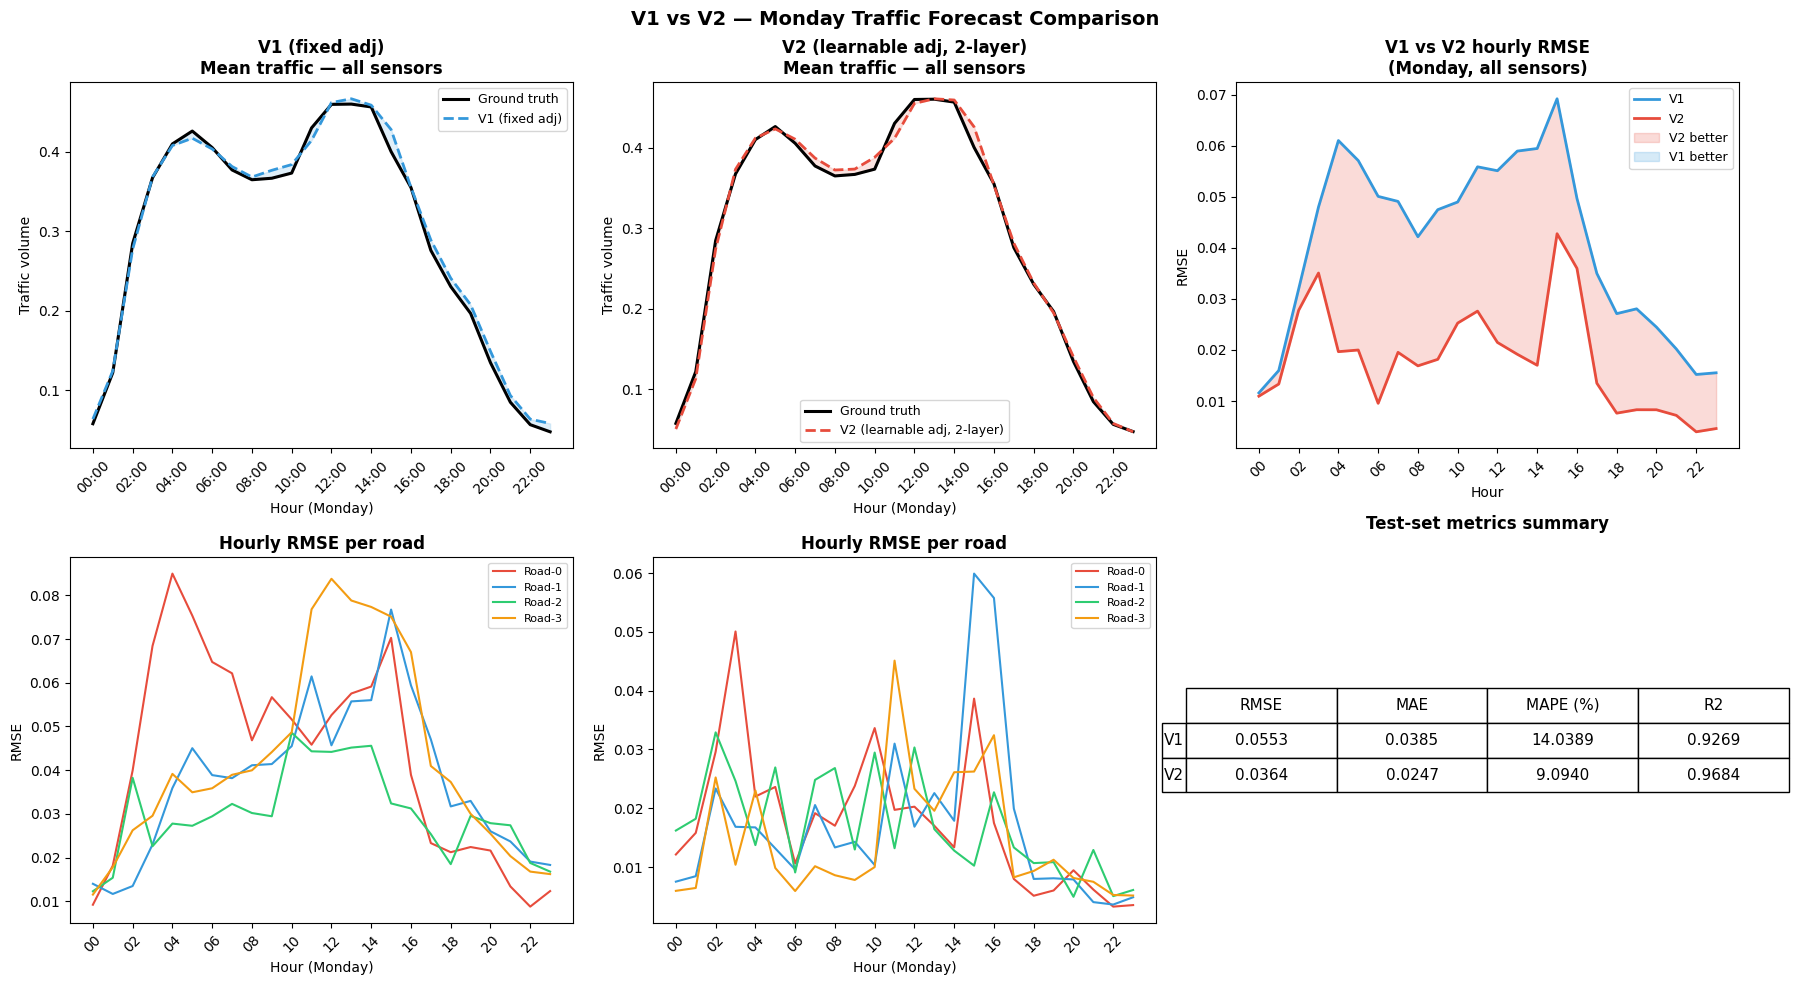

Saved monday_comparison.png

== Final comparison ==
                                          RMSE       MAE   MAPE (%)        R²
Model                                                                        
V1  GRU-GCN (fixed adj)               0.055267  0.038453  14.038864  0.926947
V2  GRU-GCN (learnable adj, 2-layer)  0.036367  0.024723   9.094002  0.968368


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
hours = np.arange(24)

for col, (pred, name, col_c) in enumerate(zip(
        [typical_mon_p1, typical_mon_p2],
        ["V1 (fixed adj)", "V2 (learnable adj, 2-layer)"],
        ["#3498db", "#e74c3c"])):

    # ── Panel top: mean across all sensors
    ax = axes[0, col]
    ax.plot(hours, typical_mon_true.mean(axis=1), 'k-',  linewidth=2.2, label='Ground truth')
    ax.plot(hours, pred.mean(axis=1),             color=col_c, linewidth=2, linestyle='--', label=name)
    ax.fill_between(hours, typical_mon_true.mean(1), pred.mean(1), alpha=0.15, color=col_c)
    ax.set_title(f"{name}\nMean traffic — all sensors", fontweight='bold')
    ax.set_xlabel("Hour (Monday)"); ax.set_ylabel("Traffic volume")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 24, 2)], rotation=45)
    ax.legend(fontsize=9)

    # ── Panel bottom: per-road RMSE over the day
    ax = axes[1, col]
    road_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
    for r in range(4):
        mask = road_id == r
        if not mask.any(): continue
        rmse_per_hour = np.sqrt(np.mean((pred[:, mask] - typical_mon_true[:, mask])**2, axis=1))
        ax.plot(hours, rmse_per_hour, color=road_colors[r], linewidth=1.5,
                label=ROAD_LABELS[r].split(' (')[0])
    ax.set_title(f"Hourly RMSE per road", fontweight='bold')
    ax.set_xlabel("Hour (Monday)"); ax.set_ylabel("RMSE")
    ax.set_xticks(range(0, 24, 2))
    ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 2)], rotation=45)
    ax.legend(fontsize=8)

# ── Panel right: V1 vs V2 hourly RMSE overlay
ax = axes[0, 2]
rmse1 = np.sqrt(np.mean((typical_mon_p1 - typical_mon_true)**2, axis=1))
rmse2 = np.sqrt(np.mean((typical_mon_p2 - typical_mon_true)**2, axis=1))
ax.plot(hours, rmse1, '#3498db', linewidth=2, label='V1')
ax.plot(hours, rmse2, '#e74c3c', linewidth=2, label='V2')
ax.fill_between(hours, rmse1, rmse2,
                where=(rmse2 < rmse1), alpha=0.2, color='#e74c3c', label='V2 better')
ax.fill_between(hours, rmse1, rmse2,
                where=(rmse1 < rmse2), alpha=0.2, color='#3498db', label='V1 better')
ax.set_title("V1 vs V2 hourly RMSE\n(Monday, all sensors)", fontweight='bold')
ax.set_xlabel("Hour"); ax.set_ylabel("RMSE")
ax.set_xticks(range(0, 24, 2))
ax.set_xticklabels([f"{h:02d}" for h in range(0, 24, 2)], rotation=45)
ax.legend(fontsize=9)

# ── Panel bottom-right: metric table
ax = axes[1, 2]
ax.axis('off')
col_labels = ["RMSE", "MAE", "MAPE (%)", "R2"]
row_labels = ["V1", "V2"]
table_data = [[f"{df_metrics.iloc[i][c]:.4f}" for c in df_metrics.columns]
              for i in range(len(df_metrics))]
tbl = ax.table(cellText=table_data, rowLabels=row_labels, colLabels=col_labels,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11)
tbl.scale(1.2, 2)
ax.set_title("Test-set metrics summary", fontweight='bold', pad=20)

plt.suptitle("V1 vs V2 — Monday Traffic Forecast Comparison", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("monday_comparison.png", dpi=130, bbox_inches='tight')
plt.show()
print("Saved monday_comparison.png")
print()
print("== Final comparison ==")
print(df_metrics.to_string())


## Summary

| Output | Description |
|---|---|
| `animation_v1_monday.html` | Animated Monday — V1 predictions vs ground truth |
| `animation_v2_monday.html` | Animated Monday — V2 predictions vs ground truth |
| `comparison_scatter.png` | Predicted vs actual scatter for both models |
| `learned_adj.png` | What V2 learned about edge strengths vs fixed topology |
| `monday_comparison.png` | Side-by-side hourly profile and RMSE comparison |

**How to read the animations**: node size and colour represent predicted traffic volume
(yellow=low, red=high). Hover over any sensor for predicted vs actual values.
Use the play button or slider to step through the 24 hours of a typical Monday.
